# Dataset Visualization & Inference

Part 1 picks a random image from the YOLO dataset built by `data_preparation.py` and plots it with its ground-truth classes and bounding boxes.

Part 2 runs a trained (or pretrained) YOLO model on an image and plots the predicted boxes.

In [ ]:
!pip install opencv-python-headless==4.10.0.84

In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import yaml

In [ ]:
!pip freeze

In [2]:
DATA_YAML = Path("./dataset/data.yaml")

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

DATASET_ROOT = Path("./dataset")
CLASS_NAMES = [data_cfg["names"][i] for i in sorted(data_cfg["names"])]
COLORS = plt.get_cmap("tab10").colors

print(f"Dataset root: {DATASET_ROOT}")
print(f"Classes: {CLASS_NAMES}")

Dataset root: dataset
Classes: ['Tohid', 'Mreza', 'Mahdi']


## Part 1 — visualize a random ground-truth sample

In [3]:
def load_yolo_labels(label_path):
    """Return a list of (class_id, x_center, y_center, width, height), all normalized [0, 1]."""
    if not label_path.exists():
        return []
    boxes = []
    for line in label_path.read_text().strip().splitlines():
        if not line:
            continue
        cls_id, x, y, w, h = line.split()
        boxes.append((int(cls_id), float(x), float(y), float(w), float(h)))
    return boxes


def plot_boxes(image_rgb, boxes, class_names, title=None, box_format="yolo"):
    """box_format: 'yolo' -> (class_id, xc, yc, w, h) normalized.
    'xyxy' -> (class_id, x1, y1, x2, y2, confidence) in pixel coordinates."""
    img_h, img_w = image_rgb.shape[:2]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_rgb)

    for box in boxes:
        if box_format == "yolo":
            cls_id, xc, yc, w, h = box
            box_w, box_h = w * img_w, h * img_h
            x0, y0 = xc * img_w - box_w / 2, yc * img_h - box_h / 2
            label = class_names[cls_id]
        else:
            cls_id, x1, y1, x2, y2, conf = box
            x0, y0, box_w, box_h = x1, y1, x2 - x1, y2 - y1
            label = f"{class_names[cls_id]} {conf:.2f}"

        color = COLORS[cls_id % len(COLORS)]
        ax.add_patch(patches.Rectangle((x0, y0), box_w, box_h, linewidth=2, edgecolor=color, facecolor="none"))
        ax.text(
            x0, max(y0 - 5, 0), label, color="white", fontsize=10,
            bbox=dict(facecolor=color, alpha=0.8, pad=1),
        )

    ax.set_title(title or "")
    ax.axis("off")
    plt.show()

In [ ]:
SPLIT = "train"  # or "val"

images_dir = DATASET_ROOT / "images" / SPLIT
labels_dir = DATASET_ROOT / "labels" / SPLIT

image_files = sorted(
    p for p in images_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
if not image_files:
    raise SystemExit(f"No images found in {images_dir} — run data_preparation.py first.")

random_image_path = random.choice(image_files)
random_label_path = labels_dir / f"{random_image_path.stem}.txt"

image_bgr = cv2.imread(str(random_image_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
boxes = load_yolo_labels(random_label_path)

plot_boxes(image_rgb, boxes, CLASS_NAMES, title=f"{SPLIT}/{random_image_path.name}", box_format="yolo")

## Part 2 — run inference with a YOLO model

Requires the `ultralytics` package (`pip install ultralytics`). Loads your trained weights from `train.py`'s output directory if present, otherwise falls back to the pretrained checkpoint.

In [4]:
from ultralytics import YOLO

TRAINED_WEIGHTS = Path("runs/face_vision/weights/best.pt")
MODEL_PATH = TRAINED_WEIGHTS if TRAINED_WEIGHTS.exists() else Path("yolo12n.pt")

model = YOLO(str(MODEL_PATH))
print(f"Loaded model: {MODEL_PATH}")

Loaded model: runs/face_vision/weights/best.pt


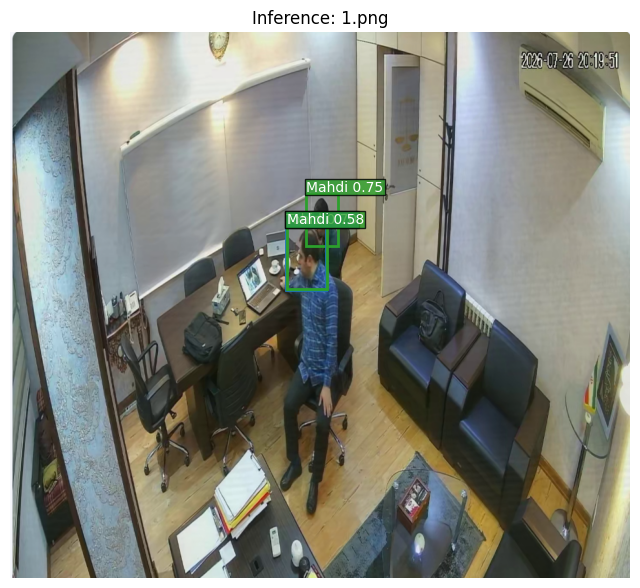

Mahdi: 0.75
Tohid: 0.70
Mahdi: 0.58


In [6]:
# Set this to any image you want to run inference on.
inference_image_path = Path("1.png")

results = model.predict(source=str(inference_image_path), conf=0.25, verbose=False)
result = results[0]

pred_image_rgb = cv2.cvtColor(cv2.imread(str(inference_image_path)), cv2.COLOR_BGR2RGB)
predicted_boxes = [
    (int(box.cls[0]), *box.xyxy[0].tolist(), float(box.conf[0]))
    for box in result.boxes
]

plot_boxes(
    pred_image_rgb, predicted_boxes, CLASS_NAMES,
    title=f"Inference: {Path(inference_image_path).name}", box_format="xyxy",
)

for cls_id, *_, conf in predicted_boxes:
    print(f"{CLASS_NAMES[cls_id]}: {conf:.2f}")

## Part 3 — training curves (classification loss & total loss)

Reads `results.csv` written by `train.py` (under `--project/--name`, default `runs/face_vision`) and plots train vs. validation classification loss and train vs. validation total loss per epoch.

In [ ]:
!pip install pandas

In [ ]:
import pandas as pd

RUN_DIR = Path("runs/face_vision")
results_csv = RUN_DIR / "results.csv"
if not results_csv.exists():
    raise SystemExit(f"{results_csv} not found — train a model first (training/train.py).")

results_df = pd.read_csv(results_csv)
results_df.columns = [c.strip() for c in results_df.columns]

TRAIN_COLOR, VAL_COLOR = "#2a78d6", "#eb6834"  # categorical slots 1 & 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(results_df["epoch"], results_df["train/cls_loss"], color=TRAIN_COLOR, linewidth=2, label="train")
axes[0].plot(results_df["epoch"], results_df["val/cls_loss"], color=VAL_COLOR, linewidth=2, label="val")
axes[0].set_title("Classification loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cls_loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(results_df["epoch"], results_df["train/box_loss"], color=TRAIN_COLOR, linewidth=2, label="train")
axes[1].plot(results_df["epoch"], results_df["val/box_loss"], color=VAL_COLOR, linewidth=2, label="val")
axes[1].set_title("Box loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("box_loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()